# Term-Structure Lattice Model Calibration

## Ho-Lee, Black-Derman-Toy, Payer Swaption Pricing, and Real-World Calibration

This notebook converts the lecture slides into a clean Python workflow.

The main idea from the slides is simple:

> A pricing model is useful only when it can reproduce observed market prices of liquid instruments.

For a short-rate lattice, we first specify the short-rate dynamics, then calibrate the model parameters so that the model matches market zero-coupon bond prices and, when possible, liquid derivative prices.

---

## What this notebook covers

1. Why model calibration is needed
2. Ho-Lee style lattice calibration
3. Black-Derman-Toy lattice calibration
4. Forward-equation / Arrow-Debreu state-price calibration
5. Pricing a 2-into-8 payer swaption in a calibrated BDT tree
6. Why changing volatility requires recalibration
7. Practical least-squares calibration
8. A real-world template using `yfinance` option-chain data

> Educational note: This notebook is for learning and model-building practice only. It is not trading or investment advice.

# 1. Model Calibration: Core Idea

In earlier derivative-pricing examples, model parameters are often given.
In real markets, parameters are not known directly. We infer them from liquid market instruments.

For a short-rate lattice, the model has node-level rates:

$$
r_{i,j}, \quad i=0,1,\ldots,n-1, \quad j=0,1,\ldots,i.
$$

Here:

- $i$ is the time step,
- $j$ is the node index at that time step,
- $r_{i,j}$ is the one-period short rate at node $(i,j)$.

A full tree has too many free parameters. Therefore, we restrict the rate structure.

## Ho-Lee style parameterization

$$
r_{i,j}=a_i+b_i j.
$$

This is simple, but it can produce negative rates if parameters are not controlled.

## Black-Derman-Toy parameterization

$$
r_{i,j}=a_i e^{b_i j}.
$$

This is useful because the exponential form keeps rates positive when $a_i>0$.

In the lecture, the risk-neutral transition probability is fixed at:

$$
q=1-q=\frac{1}{2}.
$$

So the calibration task becomes:

> Choose model parameters so that model prices match market prices.

In [1]:
import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq, minimize, minimize_scalar
from scipy.stats import norm

pd.set_option("display.float_format", lambda x: f"{x:,.8f}")

# 2. Market Inputs: Spot Rates and Zero-Coupon Bond Prices

The slides calibrate the BDT tree to the observed term structure.

If the market spot rate for maturity $i$ is $s_i$, compounded once per period, then the zero-coupon bond price is:

$$
P(0,i)=\frac{1}{(1+s_i)^i}.
$$

In real applications, we would use market zero-coupon prices or a bootstrapped zero curve.
The PDF does not include the original Excel market curve, so this notebook uses a reproducible toy curve.

You can replace `spot_rates` with your real market curve.

In [2]:
def zcb_prices_from_spot_rates(spot_rates: np.ndarray) -> np.ndarray:
    """
    Convert annual spot rates into zero-coupon bond prices.

    Parameters
    ----------
    spot_rates:
        Array where spot_rates[i-1] is the i-year spot rate.
        Example: spot_rates[0] is the 1-year spot rate.

    Returns
    -------
    np.ndarray
        Array where output[i-1] is P(0, i).
    """
    spot_rates = np.asarray(spot_rates, dtype=float)
    maturities = np.arange(1, len(spot_rates) + 1)
    return 1.0 / (1.0 + spot_rates) ** maturities


# Toy 10-year annual spot curve.
# Replace this with the actual curve from your market/assignment if available.
spot_rates = np.array([
    0.0900, 0.0920, 0.0940, 0.0960, 0.0980,
    0.1000, 0.1020, 0.1040, 0.1060, 0.1080,
])

zcb_market = zcb_prices_from_spot_rates(spot_rates)

market_curve = pd.DataFrame({
    "maturity_year": np.arange(1, len(spot_rates) + 1),
    "spot_rate": spot_rates,
    "market_zcb_price": zcb_market,
})

market_curve

,maturity_year,spot_rate,market_zcb_price
0,1,0.09000000,0.91743119
1,2,0.09200000,0.83859974
2,3,0.09400000,0.76374439
3,4,0.09600000,0.69303917
4,5,0.09800000,0.62659698
5,6,0.10000000,0.56447393
6,7,0.10200000,0.50667426
7,8,0.10400000,0.45315566
8,9,0.10600000,0.40383491
9,10,0.10800000,0.35859349


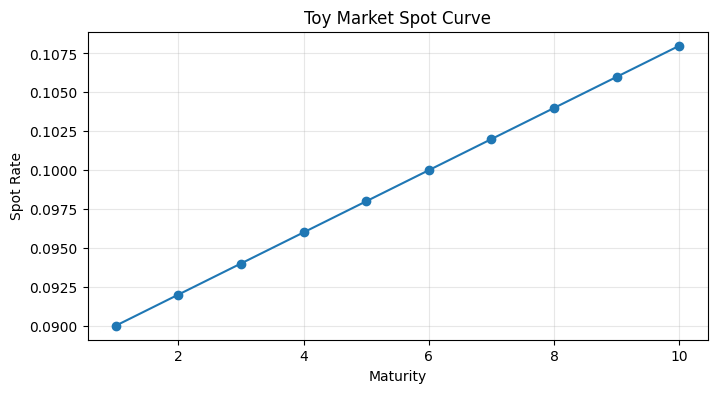

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(market_curve["maturity_year"], market_curve["spot_rate"], marker="o")
plt.title("Toy Market Spot Curve")
plt.xlabel("Maturity")
plt.ylabel("Spot Rate")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Arrow-Debreu State Prices and the Forward Equation

The BDT calibration in the slides uses forward equations.

Let:

$$
\widetilde{P}_{i,j}
$$

be the Arrow-Debreu state price at node $(i,j)$.

Interpretation:

> $\widetilde{P}_{i,j}$ is the time-0 price of receiving $1$ only if the tree reaches node $(i,j)$.

With equal risk-neutral probabilities $q=1/2$, state prices move forward as:

$$
\widetilde{P}_{i+1,0}
=\frac{\widetilde{P}_{i,0}}{2(1+r_{i,0})},
$$

$$
\widetilde{P}_{i+1,j}
=\frac{\widetilde{P}_{i,j}}{2(1+r_{i,j})}
+\frac{\widetilde{P}_{i,j-1}}{2(1+r_{i,j-1})},
\quad j=1,\ldots,i,
$$

$$
\widetilde{P}_{i+1,i+1}
=\frac{\widetilde{P}_{i,i}}{2(1+r_{i,i})}.
$$

The model-implied zero-coupon price for maturity $i$ is the sum of all state prices at time $i$:

$$
P^{model}(0,i)=\sum_{j=0}^{i}\widetilde{P}_{i,j}.
$$

Calibration forces:

$$
P^{model}(0,i)=P^{market}(0,i).
$$

In [4]:
def next_state_prices(prev_state_prices: np.ndarray, short_rates_at_time: np.ndarray) -> np.ndarray:
    """
    Move Arrow-Debreu state prices one step forward.

    Parameters
    ----------
    prev_state_prices:
        State prices at time i, length i+1.
    short_rates_at_time:
        Short rates r_{i,j}, length i+1.

    Returns
    -------
    np.ndarray
        State prices at time i+1, length i+2.
    """
    prev_state_prices = np.asarray(prev_state_prices, dtype=float)
    short_rates_at_time = np.asarray(short_rates_at_time, dtype=float)

    if len(prev_state_prices) != len(short_rates_at_time):
        raise ValueError("prev_state_prices and short_rates_at_time must have the same length.")

    i = len(prev_state_prices) - 1
    nxt = np.zeros(i + 2)

    discounted = prev_state_prices / (2.0 * (1.0 + short_rates_at_time))

    nxt[:-1] += discounted
    nxt[1:] += discounted

    return nxt


def state_price_table_to_dataframe(state_prices: List[np.ndarray]) -> pd.DataFrame:
    rows = []
    for i, layer in enumerate(state_prices):
        for j, value in enumerate(layer):
            rows.append({"time": i, "node": j, "state_price": value})
    return pd.DataFrame(rows)

# 4. Ho-Lee Calibration

The Ho-Lee style tree uses:

$$
r_{i,j}=a_i+bj.
$$

To make the example comparable to the BDT section, we assume $b$ is fixed and calibrate the sequence:

$$
a_0,a_1,\ldots,a_{n-1}.
$$

At each time step, we solve for $a_i$ so that the next maturity zero-coupon bond price matches the market price.

The practical meaning is:

- $b$ controls the spread between nodes,
- $a_i$ shifts the whole layer up or down,
- calibration chooses $a_i$ to match the market discount curve.

In [5]:
@dataclass
class LatticeCalibrationResult:
    model_name: str
    parameter_a: np.ndarray
    volatility_b: float
    rate_lattice: List[np.ndarray]
    state_prices: List[np.ndarray]
    calibration_table: pd.DataFrame


def calibrate_holee_to_zcb(zcb_market: np.ndarray, b: float) -> LatticeCalibrationResult:
    """
    Calibrate a Ho-Lee style short-rate tree to market ZCB prices.

    Model:
        r_{i,j} = a_i + b*j

    Parameters
    ----------
    zcb_market:
        Market zero-coupon prices P(0,1), ..., P(0,n).
    b:
        Fixed node-spacing parameter.
    """
    zcb_market = np.asarray(zcb_market, dtype=float)
    n = len(zcb_market)

    a_values = []
    rate_lattice = []
    state_prices = [np.array([1.0])]

    for i in range(n):
        prev_state = state_prices[-1]
        nodes = np.arange(i + 1)

        def objective(a_i: float) -> float:
            rates = a_i + b * nodes
            if np.any(1.0 + rates <= 0):
                return np.inf
            nxt = next_state_prices(prev_state, rates)
            return float(nxt.sum() - zcb_market[i])

        lower = -0.95
        upper = 5.00

        # Expand the upper bracket if needed.
        while objective(lower) * objective(upper) > 0:
            upper *= 2
            if upper > 1_000:
                raise RuntimeError("Could not bracket Ho-Lee root. Check inputs.")

        a_i = brentq(objective, lower, upper)
        rates_i = a_i + b * nodes
        nxt_state = next_state_prices(prev_state, rates_i)

        a_values.append(a_i)
        rate_lattice.append(rates_i)
        state_prices.append(nxt_state)

    calibration_table = pd.DataFrame({
        "maturity": np.arange(1, n + 1),
        "market_zcb": zcb_market,
        "model_zcb": [layer.sum() for layer in state_prices[1:]],
        "abs_error": np.abs(zcb_market - np.array([layer.sum() for layer in state_prices[1:]])),
        "a_i": a_values,
    })

    return LatticeCalibrationResult(
        model_name="Ho-Lee",
        parameter_a=np.array(a_values),
        volatility_b=b,
        rate_lattice=rate_lattice,
        state_prices=state_prices,
        calibration_table=calibration_table,
    )


holee_result = calibrate_holee_to_zcb(zcb_market=zcb_market, b=0.005)
holee_result.calibration_table

,maturity,market_zcb,model_zcb,abs_error,a_i
0,1,0.91743119,0.91743119,0.00000000,0.09000000
1,2,0.83859974,0.83859974,0.00000000,0.09150938
2,3,0.76374439,0.76374439,0.00000000,0.09302809
3,4,0.69303917,0.69303917,0.00000000,0.09455608
4,5,0.62659698,0.62659698,0.00000000,0.09609328
5,6,0.56447393,0.56447393,0.00000000,0.09763964
6,7,0.50667426,0.50667426,0.00000000,0.09919512
7,8,0.45315566,0.45315566,0.00000000,0.10075966
8,9,0.40383491,0.40383491,0.00000000,0.10233320
9,10,0.35859349,0.35859349,0.00000000,0.10391569


# 5. Black-Derman-Toy Calibration

The BDT short-rate tree uses:

$$
r_{i,j}=a_i e^{bj}.
$$

In the lecture version, $b_i=b$ is assumed known and constant.
Therefore, we calibrate only:

$$
a_0,a_1,\ldots,a_{n-1}.
$$

At every maturity, we choose the next $a_i$ so that:

$$
\sum_{j=0}^{i+1}\widetilde{P}_{i+1,j}=P^{market}(0,i+1).
$$

This is exactly what the forward-equation method does.

In [6]:
def calibrate_bdt_to_zcb(zcb_market: np.ndarray, b: float) -> LatticeCalibrationResult:
    """
    Calibrate a BDT short-rate tree to market ZCB prices.

    Model:
        r_{i,j} = a_i * exp(b*j)

    Parameters
    ----------
    zcb_market:
        Market zero-coupon prices P(0,1), ..., P(0,n).
    b:
        Fixed log-rate volatility / node-spacing parameter.
    """
    zcb_market = np.asarray(zcb_market, dtype=float)
    n = len(zcb_market)

    a_values = []
    rate_lattice = []
    state_prices = [np.array([1.0])]

    for i in range(n):
        prev_state = state_prices[-1]
        nodes = np.arange(i + 1)

        def objective(a_i: float) -> float:
            rates = a_i * np.exp(b * nodes)
            nxt = next_state_prices(prev_state, rates)
            return float(nxt.sum() - zcb_market[i])

        lower = 1e-12
        upper = 5.00

        while objective(lower) * objective(upper) > 0:
            upper *= 2
            if upper > 1_000:
                raise RuntimeError("Could not bracket BDT root. Check inputs.")

        a_i = brentq(objective, lower, upper)
        rates_i = a_i * np.exp(b * nodes)
        nxt_state = next_state_prices(prev_state, rates_i)

        a_values.append(a_i)
        rate_lattice.append(rates_i)
        state_prices.append(nxt_state)

    model_zcb = np.array([layer.sum() for layer in state_prices[1:]])

    calibration_table = pd.DataFrame({
        "maturity": np.arange(1, n + 1),
        "market_zcb": zcb_market,
        "model_zcb": model_zcb,
        "abs_error": np.abs(zcb_market - model_zcb),
        "a_i": a_values,
    })

    return LatticeCalibrationResult(
        model_name="BDT",
        parameter_a=np.array(a_values),
        volatility_b=b,
        rate_lattice=rate_lattice,
        state_prices=state_prices,
        calibration_table=calibration_table,
    )


bdt_result_005 = calibrate_bdt_to_zcb(zcb_market=zcb_market, b=0.005)
bdt_result_005.calibration_table

,maturity,market_zcb,model_zcb,abs_error,a_i
0,1,0.91743119,0.91743119,0.00000000,0.09000000
1,2,0.83859974,0.83859974,0.00000000,0.09376871
2,3,0.76374439,0.76374439,0.00000000,0.09752172
3,4,0.69303917,0.69303917,0.00000000,0.10125906
4,5,0.62659698,0.62659698,0.00000000,0.10498078
5,6,0.56447393,0.56447393,0.00000000,0.10868692
6,7,0.50667426,0.50667426,0.00000000,0.11237754
7,8,0.45315566,0.45315566,0.00000000,0.11605267
8,9,0.40383491,0.40383491,0.00000000,0.11971237
9,10,0.35859349,0.35859349,0.00000000,0.12335667


In [7]:
def lattice_to_dataframe(lattice: List[np.ndarray], value_name: str) -> pd.DataFrame:
    rows = []
    for i, layer in enumerate(lattice):
        for j, value in enumerate(layer):
            rows.append({"time": i, "node": j, value_name: value})
    return pd.DataFrame(rows)


bdt_rates_df = lattice_to_dataframe(bdt_result_005.rate_lattice, "short_rate")
bdt_state_prices_df = state_price_table_to_dataframe(bdt_result_005.state_prices)

bdt_rates_df.head(15)

,time,node,short_rate
0,0,0,0.09000000
1,1,0,0.09376871
2,1,1,0.09423873
3,2,0,0.09752172
4,2,1,0.09801055
5,2,2,0.09850183
6,3,0,0.10125906
7,3,1,0.10176662
8,3,2,0.10227673
9,3,3,0.10278939


## Compare Ho-Lee and BDT calibrated short-rate trees

Both models are calibrated to the same zero-coupon curve.
However, they produce different internal short-rate trees.

This matters because path-dependent and option-like securities, such as swaptions, depend not only on today’s discount curve but also on the future distribution of rates.

In [8]:
compare_a = pd.DataFrame({
    "time": np.arange(len(zcb_market)),
    "Ho_Lee_a_i": holee_result.parameter_a,
    "BDT_a_i_b_005": bdt_result_005.parameter_a,
})
compare_a

,time,Ho_Lee_a_i,BDT_a_i_b_005
0,0,0.09000000,0.09000000
1,1,0.09150938,0.09376871
2,2,0.09302809,0.09752172
3,3,0.09455608,0.10125906
4,4,0.09609328,0.10498078
5,5,0.09763964,0.10868692
6,6,0.09919512,0.11237754
7,7,0.10075966,0.11605267
8,8,0.10233320,0.11971237
9,9,0.10391569,0.12335667


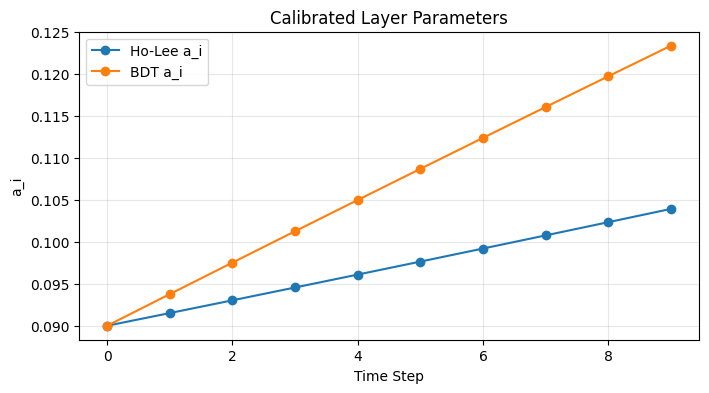

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(compare_a["time"], compare_a["Ho_Lee_a_i"], marker="o", label="Ho-Lee a_i")
plt.plot(compare_a["time"], compare_a["BDT_a_i_b_005"], marker="o", label="BDT a_i")
plt.title("Calibrated Layer Parameters")
plt.xlabel("Time Step")
plt.ylabel("a_i")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Generic Backward Induction Pricing

After calibration, we price derivatives by backward induction under the risk-neutral measure.

If a claim has value $V_{i+1,j}$ and $V_{i+1,j+1}$ in the next period, then the value at node $(i,j)$ is:

$$
V_{i,j}=\frac{1}{1+r_{i,j}}\left(\frac{1}{2}V_{i+1,j}+\frac{1}{2}V_{i+1,j+1}\right).
$$

This is the one-period risk-neutral discounted expectation.

In [10]:
def backward_induction_from_layer(
    rate_lattice: List[np.ndarray],
    terminal_values: np.ndarray,
    start_time: int = 0,
    terminal_time: Optional[int] = None,
) -> List[np.ndarray]:
    """
    Backward-induct values from terminal_time to start_time.

    Parameters
    ----------
    rate_lattice:
        List of short-rate layers. rate_lattice[i] has length i+1.
    terminal_values:
        Values at terminal_time, length terminal_time+1.
    start_time:
        Time to discount back to.
    terminal_time:
        Terminal time. If None, inferred from len(terminal_values)-1.

    Returns
    -------
    List[np.ndarray]
        Value layers from start_time to terminal_time.
        output[0] corresponds to start_time.
    """
    if terminal_time is None:
        terminal_time = len(terminal_values) - 1

    values_by_time: Dict[int, np.ndarray] = {terminal_time: np.asarray(terminal_values, dtype=float)}

    for i in range(terminal_time - 1, start_time - 1, -1):
        next_values = values_by_time[i + 1]
        rates = rate_lattice[i]
        current = (0.5 * next_values[:-1] + 0.5 * next_values[1:]) / (1.0 + rates)
        values_by_time[i] = current

    return [values_by_time[i] for i in range(start_time, terminal_time + 1)]


def zcb_price_lattice(rate_lattice: List[np.ndarray], maturity: int) -> List[np.ndarray]:
    """
    Compute node-level prices P(i,j;maturity) of a zero-coupon bond paying 1 at maturity.
    """
    terminal = np.ones(maturity + 1)
    return backward_induction_from_layer(
        rate_lattice=rate_lattice,
        terminal_values=terminal,
        start_time=0,
        terminal_time=maturity,
    )


# Check that backward induction reproduces market ZCB prices after BDT calibration.
check_rows = []
for maturity in range(1, len(zcb_market) + 1):
    price_tree = zcb_price_lattice(bdt_result_005.rate_lattice, maturity)
    check_rows.append({
        "maturity": maturity,
        "market_zcb": zcb_market[maturity - 1],
        "backward_model_zcb": price_tree[0][0],
        "abs_error": abs(price_tree[0][0] - zcb_market[maturity - 1]),
    })

pd.DataFrame(check_rows)

,maturity,market_zcb,backward_model_zcb,abs_error
0,1,0.91743119,0.91743119,0.00000000
1,2,0.83859974,0.83859974,0.00000000
2,3,0.76374439,0.76374439,0.00000000
3,4,0.69303917,0.69303917,0.00000000
4,5,0.62659698,0.62659698,0.00000000
5,6,0.56447393,0.56447393,0.00000000
6,7,0.50667426,0.50667426,0.00000000
7,8,0.45315566,0.45315566,0.00000000
8,9,0.40383491,0.40383491,0.00000000
9,10,0.35859349,0.35859349,0.00000000


# 7. Pricing a 2-into-8 Payer Swaption in the BDT Tree

The slides price a 2-into-8 payer swaption.

Meaning:

- The option is exercised at year 2.
- If exercised, the holder enters an 8-year swap.
- Payments happen in years 3 through 10.
- The holder pays fixed and receives floating.
- The fixed rate in the lecture example is $11.65\%$.

Let $t_e=2$ be the exercise time and $T=10$ be the final swap maturity.
At each node at time $t_e$, the payer swap value is:

$$
S_{t_e,j}=N\left[1-P(t_e,j;T)-K\sum_{m=t_e+1}^{T}P(t_e,j;m)\right].
$$

where:

- $N$ is notional,
- $K$ is the fixed swap rate,
- $P(t_e,j;m)$ is the node-level price of a zero-coupon bond maturing at time $m$.

The payer swaption payoff at exercise is:

$$
\max(S_{t_e,j},0).
$$

Then we discount this payoff back to time 0 using backward induction.

In [11]:
def node_zcb_prices_for_maturities(
    rate_lattice: List[np.ndarray],
    node_time: int,
    maturities: List[int],
) -> Dict[int, np.ndarray]:
    """
    For each maturity m, return P(node_time, j; m) for all nodes j at node_time.
    """
    out = {}
    for maturity in maturities:
        if maturity <= node_time:
            raise ValueError("Each maturity must be greater than node_time.")
        full_tree = zcb_price_lattice(rate_lattice, maturity=maturity)
        out[maturity] = full_tree[node_time]
    return out


def payer_swap_values_at_exercise(
    rate_lattice: List[np.ndarray],
    exercise_time: int,
    swap_maturity: int,
    fixed_rate: float,
    notional: float = 1.0,
) -> pd.DataFrame:
    """
    Compute payer swap values at each exercise node.

    Payer swap value = floating leg PV - fixed leg PV.
    For annual payments and unit accrual:
        floating leg PV = 1 - P(t, T)
        fixed leg PV = K * sum_{m=t+1}^{T} P(t, m)
    """
    payment_times = list(range(exercise_time + 1, swap_maturity + 1))
    zcbs = node_zcb_prices_for_maturities(rate_lattice, exercise_time, payment_times)

    p_to_final = zcbs[swap_maturity]
    annuity = np.zeros(exercise_time + 1)
    for m in payment_times:
        annuity += zcbs[m]

    floating_leg = notional * (1.0 - p_to_final)
    fixed_leg = notional * fixed_rate * annuity
    swap_value = floating_leg - fixed_leg
    payoff = np.maximum(swap_value, 0.0)

    return pd.DataFrame({
        "exercise_time": exercise_time,
        "node": np.arange(exercise_time + 1),
        "P_to_final": p_to_final,
        "swap_annuity": annuity,
        "floating_leg_value": floating_leg,
        "fixed_leg_value": fixed_leg,
        "payer_swap_value": swap_value,
        "swaption_payoff": payoff,
    })


def price_payer_swaption_bdt(
    rate_lattice: List[np.ndarray],
    exercise_time: int,
    swap_maturity: int,
    fixed_rate: float,
    notional: float = 1.0,
) -> Tuple[float, pd.DataFrame, List[np.ndarray]]:
    """
    Price a European payer swaption by:
    1. Computing payer swap value at exercise nodes.
    2. Taking max(value, 0).
    3. Discounting back to time 0.
    """
    exercise_df = payer_swap_values_at_exercise(
        rate_lattice=rate_lattice,
        exercise_time=exercise_time,
        swap_maturity=swap_maturity,
        fixed_rate=fixed_rate,
        notional=notional,
    )

    payoff = exercise_df["swaption_payoff"].to_numpy()
    value_layers = backward_induction_from_layer(
        rate_lattice=rate_lattice,
        terminal_values=payoff,
        start_time=0,
        terminal_time=exercise_time,
    )

    return float(value_layers[0][0]), exercise_df, value_layers


exercise_time = 2
swap_maturity = 10
fixed_rate = 0.1165
notional = 1_000_000

swaption_price_005, exercise_df_005, swaption_tree_005 = price_payer_swaption_bdt(
    rate_lattice=bdt_result_005.rate_lattice,
    exercise_time=exercise_time,
    swap_maturity=swap_maturity,
    fixed_rate=fixed_rate,
    notional=notional,
)

print(f"BDT payer swaption price, b=0.005: ${swaption_price_005:,.2f}")
exercise_df_005

BDT payer swaption price, b=0.005: $0.00


,exercise_time,node,P_to_final,swap_annuity,floating_leg_value,fixed_leg_value,payer_swap_value,swaption_payoff
0,2,0,0.42933214,5.22108107,"570,667.85823650","608,255.94463352","-37,588.08639701",0.00000000
1,2,1,0.42760984,5.21120590,"572,390.16220366","607,105.48749808","-34,715.32529442",0.00000000
2,2,2,0.42588673,5.20131160,"574,113.26704682","605,952.80169749","-31,839.53465067",0.00000000


# 8. Volatility Sensitivity and Recalibration

The lecture emphasizes an important point:

> If we change $b$, we must recalibrate the model.

Why?

Because $b$ changes the future distribution of short rates. The zero-coupon curve only pins down discount prices. It does not fully determine the volatility structure.

So two BDT trees can both match the same zero-coupon bond prices but still produce different swaption prices.

This is why a production calibration should use instruments close to the product being priced.
For a swaption, liquid swaption prices are much better calibration instruments than only zero-coupon bonds.

In [12]:
def calibrate_and_price_swaption_for_b(
    b: float,
    zcb_market: np.ndarray,
    exercise_time: int,
    swap_maturity: int,
    fixed_rate: float,
    notional: float,
) -> Dict[str, float]:
    result = calibrate_bdt_to_zcb(zcb_market=zcb_market, b=b)
    price, _, _ = price_payer_swaption_bdt(
        rate_lattice=result.rate_lattice,
        exercise_time=exercise_time,
        swap_maturity=swap_maturity,
        fixed_rate=fixed_rate,
        notional=notional,
    )
    max_zcb_error = result.calibration_table["abs_error"].max()
    return {"b": b, "swaption_price": price, "max_zcb_error": max_zcb_error}


vol_scenarios = [0.0000, 0.0025, 0.0050, 0.0075, 0.0100, 0.0150, 0.0200]
vol_sensitivity = pd.DataFrame([
    calibrate_and_price_swaption_for_b(
        b=b,
        zcb_market=zcb_market,
        exercise_time=exercise_time,
        swap_maturity=swap_maturity,
        fixed_rate=fixed_rate,
        notional=notional,
    )
    for b in vol_scenarios
])

vol_sensitivity

,b,swaption_price,max_zcb_error
0,0.00000000,0.00000000,0.00000000
1,0.00250000,0.00000000,0.00000000
2,0.00500000,0.00000000,0.00000000
3,0.00750000,0.00000000,0.00000000
4,0.01000000,0.00000000,0.00000000
5,0.01500000,0.00000000,0.00000000
6,0.02000000,0.00000000,0.00000000


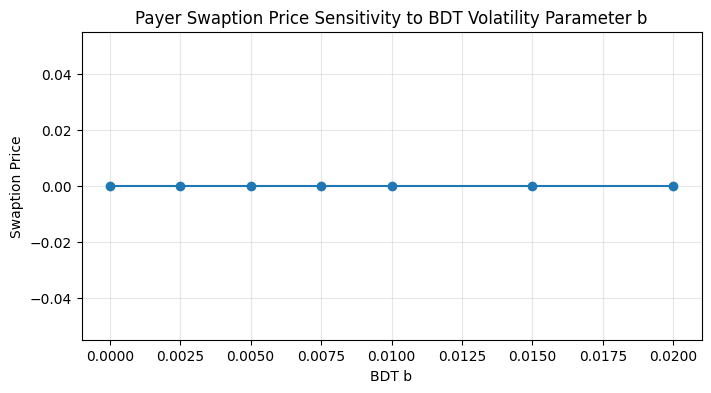

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(vol_sensitivity["b"], vol_sensitivity["swaption_price"], marker="o")
plt.title("Payer Swaption Price Sensitivity to BDT Volatility Parameter b")
plt.xlabel("BDT b")
plt.ylabel("Swaption Price")
plt.grid(True, alpha=0.3)
plt.show()

# 9. Practical Calibration as Weighted Least Squares

The slides describe real calibration as an optimization problem:

$$
\min_{\theta}
\sum_i \omega_i
\left(P_i^{\operatorname{model}}(\theta)-P_i^{\operatorname{market}}\right)^2
+
\lambda\left\|\theta-\theta_{\operatorname{prev}}\right\|^2
$$

where:

- $\theta$ is the parameter vector,
- $P_i^{model}$ is the model price of calibration instrument $i$,
- $P_i^{market}$ is the market price,
- $\omega_i$ is the weight for that instrument,
- $\lambda$ controls how much we penalize moving away from the previous calibration.

The term:

$$
\lambda\|\theta-\theta_{prev}\|^2
$$

is useful in production because it prevents parameters from jumping too aggressively when market data is noisy.

In [14]:
def practical_calibration_objective(
    model_prices: np.ndarray,
    market_prices: np.ndarray,
    weights: Optional[np.ndarray] = None,
    theta: Optional[np.ndarray] = None,
    theta_prev: Optional[np.ndarray] = None,
    lambda_reg: float = 0.0,
) -> float:
    """
    Generic weighted least-squares calibration objective.
    """
    model_prices = np.asarray(model_prices, dtype=float)
    market_prices = np.asarray(market_prices, dtype=float)

    if weights is None:
        weights = np.ones_like(market_prices)
    else:
        weights = np.asarray(weights, dtype=float)

    pricing_error = np.sum(weights * (model_prices - market_prices) ** 2)

    regularization = 0.0
    if theta is not None and theta_prev is not None and lambda_reg > 0:
        theta = np.asarray(theta, dtype=float)
        theta_prev = np.asarray(theta_prev, dtype=float)
        regularization = lambda_reg * np.sum((theta - theta_prev) ** 2)

    return float(pricing_error + regularization)

## Calibrating $b$ using a swaption price

Zero-coupon bonds determine the discount curve, but they do not uniquely determine volatility.

A practical approach:

1. Pick a trial value of $b$.
2. Recalibrate all $a_i$ to the zero-coupon curve.
3. Price the swaption.
4. Compare the model swaption price with the market swaption price.
5. Search for the $b$ that minimizes the pricing error.

Below, we create a synthetic market swaption price using one chosen $b$.
In a real desk setting, this input would come from market swaption quotes.

In [15]:
# Synthetic target, standing in for an observed liquid market swaption price.
b_true_for_synthetic_market = 0.0125
synthetic_target_price = calibrate_and_price_swaption_for_b(
    b=b_true_for_synthetic_market,
    zcb_market=zcb_market,
    exercise_time=exercise_time,
    swap_maturity=swap_maturity,
    fixed_rate=fixed_rate,
    notional=notional,
)["swaption_price"]

print(f"Synthetic market swaption price: ${synthetic_target_price:,.2f}")


def objective_for_b(b: float) -> float:
    model_price = calibrate_and_price_swaption_for_b(
        b=b,
        zcb_market=zcb_market,
        exercise_time=exercise_time,
        swap_maturity=swap_maturity,
        fixed_rate=fixed_rate,
        notional=notional,
    )["swaption_price"]
    return (model_price - synthetic_target_price) ** 2

b_fit = minimize_scalar(objective_for_b, bounds=(0.0001, 0.0500), method="bounded")

print(f"Fitted b: {b_fit.x:.8f}")
print(f"Objective value: {b_fit.fun:,.8f}")

Synthetic market swaption price: $0.00
Fitted b: 0.04999470
Objective value: 0.00000000


In [16]:
# Show that the calibrated b reproduces the synthetic swaption quote.
fitted_result = calibrate_and_price_swaption_for_b(
    b=b_fit.x,
    zcb_market=zcb_market,
    exercise_time=exercise_time,
    swap_maturity=swap_maturity,
    fixed_rate=fixed_rate,
    notional=notional,
)

pd.DataFrame([
    {"case": "synthetic market", "b": b_true_for_synthetic_market, "swaption_price": synthetic_target_price},
    {"case": "fitted model", "b": b_fit.x, "swaption_price": fitted_result["swaption_price"]},
])

,case,b,swaption_price
0,synthetic market,0.01250000,0.00000000
1,fitted model,0.04999470,0.00000000


# 10. Real-World Case A: Approximate Yield Curve from Yahoo Finance

This section gives a real-world template.

Important practical warning:

> Yahoo Finance Treasury yield tickers are not the same thing as a fully bootstrapped zero-coupon curve.

They are still useful for a learning demo because they provide observable market yield levels.
For production fixed-income pricing, you should use a proper bootstrapped curve from market instruments such as deposits, futures, swaps, and government bonds.

This cell is disabled by default because it requires internet access.
Set:

```python
RUN_YFINANCE_YIELD_EXAMPLE = True
```

when running locally.

In [18]:
RUN_YFINANCE_YIELD_EXAMPLE = True


def fetch_yfinance_treasury_yields() -> pd.DataFrame:
    """
    Fetch common Yahoo Finance Treasury yield tickers.

    The exact tickers available can change. Treat this as an educational template,
    not a production market-data feed.
    """
    import yfinance as yf

    tickers = {
        "^IRX": {"label": "13-week T-bill", "maturity_year": 0.25},
        "^FVX": {"label": "5-year Treasury", "maturity_year": 5.00},
        "^TNX": {"label": "10-year Treasury", "maturity_year": 10.00},
        "^TYX": {"label": "30-year Treasury", "maturity_year": 30.00},
    }

    rows = []
    for ticker, meta in tickers.items():
        hist = yf.Ticker(ticker).history(period="5d")
        if hist.empty:
            continue
        last_yield_pct = float(hist["Close"].dropna().iloc[-1])
        rows.append({
            "ticker": ticker,
            "label": meta["label"],
            "maturity_year": meta["maturity_year"],
            "yield_rate": last_yield_pct / 100.0,
        })

    return pd.DataFrame(rows).sort_values("maturity_year").reset_index(drop=True)


if RUN_YFINANCE_YIELD_EXAMPLE:
    yf_yields = fetch_yfinance_treasury_yields()
    display(yf_yields)

    # Interpolate to annual 1Y to 10Y points for the BDT demonstration.
    annual_maturities = np.arange(1, 11)
    annual_spots = np.interp(
        annual_maturities,
        yf_yields["maturity_year"],
        yf_yields["yield_rate"],
    )

    zcb_yf = zcb_prices_from_spot_rates(annual_spots)
    bdt_yf = calibrate_bdt_to_zcb(zcb_market=zcb_yf, b=0.005)

    display(pd.DataFrame({
        "maturity": annual_maturities,
        "approx_spot_rate": annual_spots,
        "approx_zcb": zcb_yf,
        "model_zcb": bdt_yf.calibration_table["model_zcb"],
        "abs_error": bdt_yf.calibration_table["abs_error"],
    }))
else:
    print("Skipped yfinance yield example. Set RUN_YFINANCE_YIELD_EXAMPLE=True to run locally.")

,ticker,label,maturity_year,yield_rate
0,^IRX,13-week T-bill,0.25000000,0.03590000
1,^FVX,5-year Treasury,5.00000000,0.04065000
2,^TNX,10-year Treasury,10.00000000,0.04418000
3,^TYX,30-year Treasury,30.00000000,0.04987000


,maturity,approx_spot_rate,approx_zcb,model_zcb,abs_error
0,1,0.03665000,0.96464573,0.96464573,0.00000000
1,2,0.03765000,0.92874870,0.92874870,0.00000000
2,3,0.03865000,0.89246732,0.89246732,0.00000000
3,4,0.03965000,0.85595586,0.85595586,0.00000000
4,5,0.04065000,0.81936339,0.81936339,0.00000000
5,6,0.04135600,0.78415995,0.78415995,0.00000000
6,7,0.04206200,0.74945417,0.74945417,0.00000000
7,8,0.04276800,0.71531681,0.71531681,0.00000000
8,9,0.04347400,0.68181304,0.68181304,0.00000000
9,10,0.04418000,0.64900237,0.64900237,0.00000000


# 11. Real-World Case B: Calibrating Implied Volatility from Option Prices

The slide’s practical calibration objective is general. It is not only for interest-rate models.

For an equity option example, we can calibrate Black-Scholes implied volatility to observed option prices.

The workflow is exactly the same idea:

1. Observe liquid option prices from the market.
2. Choose a model, here Black-Scholes.
3. Select a parameter, here volatility $\sigma$.
4. Minimize pricing error:

$$
\min_{\sigma}\sum_i\omega_i\left(C_i^{BS}(\sigma)-C_i^{market}\right)^2.
$$

This gives an implied volatility estimate.

This section uses `yfinance` option-chain data and is disabled by default.
Set:

```python
RUN_YFINANCE_OPTION_EXAMPLE = True
```

when running locally.

In [19]:
def black_scholes_call_price(S: float, K: float, T: float, r: float, sigma: float, q: float = 0.0) -> float:
    """
    Black-Scholes European call price with continuous dividend yield q.
    """
    if T <= 0:
        return max(S - K, 0.0)
    if sigma <= 0:
        forward_intrinsic = S * math.exp(-q * T) - K * math.exp(-r * T)
        return max(forward_intrinsic, 0.0)

    d1 = (math.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    return S * math.exp(-q * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)


def implied_vol_call(
    market_price: float,
    S: float,
    K: float,
    T: float,
    r: float,
    q: float = 0.0,
    lower: float = 1e-6,
    upper: float = 5.0,
) -> float:
    """
    Solve for Black-Scholes implied volatility of a call option.
    """
    if market_price <= 0 or T <= 0:
        return np.nan

    def f(sigma):
        return black_scholes_call_price(S, K, T, r, sigma, q) - market_price

    try:
        if f(lower) * f(upper) > 0:
            return np.nan
        return brentq(f, lower, upper)
    except Exception:
        return np.nan


def fit_flat_vol_to_calls(calls_df: pd.DataFrame, S: float, T: float, r: float, q: float = 0.0) -> Dict[str, float]:
    """
    Fit one flat volatility parameter to many call prices using weighted least squares.
    """
    data = calls_df.copy()
    data = data[(data["mid"] > 0) & (data["strike"] > 0)].dropna(subset=["mid", "strike"])

    # Prefer more liquid options if volume/open interest are available.
    weights = 1.0 + data.get("volume", pd.Series(0, index=data.index)).fillna(0).to_numpy()
    weights = weights / weights.mean()

    strikes = data["strike"].to_numpy(dtype=float)
    market = data["mid"].to_numpy(dtype=float)

    def objective(sigma: float) -> float:
        model = np.array([black_scholes_call_price(S, K, T, r, sigma, q) for K in strikes])
        return practical_calibration_objective(model, market, weights=weights)

    opt = minimize_scalar(objective, bounds=(1e-4, 3.0), method="bounded")
    return {"sigma_fit": float(opt.x), "objective": float(opt.fun), "n_options": int(len(data))}

{'sigma_fit': 0.27311829581060965, 'objective': 1.238311322866656, 'n_options': 29, 'symbol': 'AAPL', 'spot_price': 270.1700134277344, 'expiration': '2026-05-29', 'dte': 29, 'T_years': 0.07945205479452055}


,contractSymbol,strike,bid,ask,lastPrice,market_price_for_calibration,volume,openInterest,implied_vol_from_mid
1,AAPL260529C00195000,195.00000000,0.00000000,0.00000000,77.74000000,77.74000000,1,0,0.83270790
2,AAPL260529C00200000,200.00000000,0.00000000,0.00000000,74.86000000,74.86000000,2,0,0.95738527
3,AAPL260529C00205000,205.00000000,0.00000000,0.00000000,66.48000000,66.48000000,6,0,0.57540363
5,AAPL260529C00215000,215.00000000,0.00000000,0.00000000,58.88000000,58.88000000,2,0,0.71649326
7,AAPL260529C00225000,225.00000000,0.00000000,0.00000000,48.93000000,48.93000000,2,0,0.61305793
9,AAPL260529C00235000,235.00000000,0.00000000,0.00000000,37.22000000,37.22000000,2,0,0.39326956
10,AAPL260529C00240000,240.00000000,0.00000000,0.00000000,31.86000000,31.86000000,2,0,0.31888964
11,AAPL260529C00245000,245.00000000,0.00000000,0.00000000,29.44000000,29.44000000,1,0,0.42838523
12,AAPL260529C00250000,250.00000000,0.00000000,0.00000000,23.66000000,23.66000000,17,0,0.33647436
13,AAPL260529C00255000,255.00000000,0.00000000,0.00000000,18.80000000,18.80000000,2,0,0.28964615


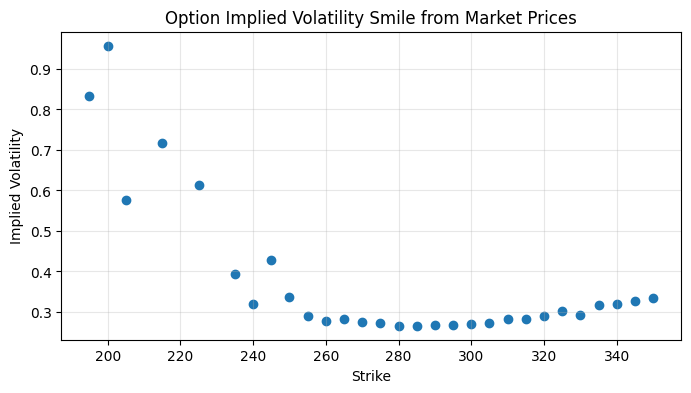

In [21]:
RUN_YFINANCE_OPTION_EXAMPLE = True


def choose_expiration_near_target(expirations, target_dte: int = 30):
    """
    Choose an expiration closest to target days-to-expiry.
    Avoid using the first expiration because it is often too close to expiry.
    """
    from datetime import datetime, timezone

    today = datetime.now(timezone.utc).date()

    expiry_info = []
    for exp in expirations:
        exp_date = pd.to_datetime(exp).date()
        dte = (exp_date - today).days
        if dte > 0:
            expiry_info.append((exp, dte))

    if not expiry_info:
        raise RuntimeError("No valid future option expirations found.")

    return min(expiry_info, key=lambda x: abs(x[1] - target_dte))


def run_yfinance_option_calibration(
    symbol: str = "AAPL",
    risk_free_rate: float = 0.04,
    target_dte: int = 30,
    min_dte: int = 7,
    strike_width: float = 0.30,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """
    Download one option chain from yfinance and calibrate implied volatility.

    Improvements:
    1. Avoids the nearest expiry if it is too close.
    2. Uses mid price when bid/ask are valid.
    3. Falls back to lastPrice if bid/ask are zero.
    4. Stops clearly if no usable option quotes remain.
    """
    import yfinance as yf
    from datetime import datetime, timezone

    ticker = yf.Ticker(symbol)

    hist = ticker.history(period="5d")
    if hist.empty:
        raise RuntimeError(f"No recent price history found for {symbol}.")

    S = float(hist["Close"].dropna().iloc[-1])

    expirations = list(ticker.options)
    if not expirations:
        raise RuntimeError(f"No option expirations found for {symbol}.")

    # Choose a more useful expiry, usually around 30 days.
    expiration, dte = choose_expiration_near_target(expirations, target_dte=target_dte)

    # If selected expiry is still too near, choose the first expiry above min_dte.
    valid_expirations = []
    today = datetime.now(timezone.utc).date()

    for exp in expirations:
        exp_date = pd.to_datetime(exp).date()
        dte_tmp = (exp_date - today).days
        if dte_tmp >= min_dte:
            valid_expirations.append((exp, dte_tmp))

    if valid_expirations:
        expiration, dte = min(valid_expirations, key=lambda x: abs(x[1] - target_dte))

    chain = ticker.option_chain(expiration)
    calls = chain.calls.copy()

    if calls.empty:
        raise RuntimeError(f"Option chain is empty for {symbol}, expiration={expiration}.")

    # Convert important columns to numeric.
    for col in ["strike", "bid", "ask", "lastPrice", "volume", "openInterest"]:
        if col in calls.columns:
            calls[col] = pd.to_numeric(calls[col], errors="coerce")

    # Use bid/ask mid when bid and ask are both valid.
    calls["mid_bid_ask"] = np.where(
        (calls["bid"] > 0) & (calls["ask"] > 0) & (calls["ask"] >= calls["bid"]),
        (calls["bid"] + calls["ask"]) / 2.0,
        np.nan,
    )

    # Fallback to lastPrice when mid is unavailable.
    calls["market_price_for_calibration"] = calls["mid_bid_ask"].fillna(calls["lastPrice"])

    expiry_date = pd.to_datetime(expiration).date()
    T = max((expiry_date - today).days / 365.0, 1 / 365)

    lower_strike = (1.0 - strike_width) * S
    upper_strike = (1.0 + strike_width) * S

    calls_clean = calls[
        (calls["market_price_for_calibration"] > 0)
        & (calls["strike"] >= lower_strike)
        & (calls["strike"] <= upper_strike)
    ].copy()

    if calls_clean.empty:
        debug = {
            "symbol": symbol,
            "spot_price": S,
            "expiration": expiration,
            "dte": dte,
            "total_calls": len(calls),
            "positive_bid_ask_mid_count": int(calls["mid_bid_ask"].notna().sum()),
            "positive_last_price_count": int((calls["lastPrice"] > 0).sum()),
            "strike_min": float(calls["strike"].min()),
            "strike_max": float(calls["strike"].max()),
            "filter_strike_low": lower_strike,
            "filter_strike_high": upper_strike,
        }
        raise RuntimeError(f"No usable option quotes after cleaning. Debug info: {debug}")

    calls_clean["model_input_S"] = S
    calls_clean["T_years"] = T
    calls_clean["risk_free_rate"] = risk_free_rate

    calls_clean["implied_vol_from_mid"] = calls_clean.apply(
        lambda row: implied_vol_call(
            market_price=float(row["market_price_for_calibration"]),
            S=S,
            K=float(row["strike"]),
            T=T,
            r=risk_free_rate,
            q=0.0,
        ),
        axis=1,
    )

    # Remove failed implied-vol calculations.
    calls_clean = calls_clean.replace([np.inf, -np.inf], np.nan)
    calls_clean = calls_clean.dropna(subset=["implied_vol_from_mid"])

    if calls_clean.empty:
        raise RuntimeError("All implied-vol calculations failed after cleaning.")

    fit = fit_flat_vol_to_calls(
        calls_clean.rename(columns={"market_price_for_calibration": "mid"}),
        S=S,
        T=T,
        r=risk_free_rate,
        q=0.0,
    )

    fit.update(
        {
            "symbol": symbol,
            "spot_price": S,
            "expiration": expiration,
            "dte": dte,
            "T_years": T,
            "n_options": len(calls_clean),
        }
    )

    return calls_clean, fit


if RUN_YFINANCE_OPTION_EXAMPLE:
    calls_clean, fit_result = run_yfinance_option_calibration(
        symbol="AAPL",
        risk_free_rate=0.04,
        target_dte=30,
        min_dte=7,
        strike_width=0.30,
    )

    print(fit_result)

    display(
        calls_clean[
            [
                "contractSymbol",
                "strike",
                "bid",
                "ask",
                "lastPrice",
                "market_price_for_calibration",
                "volume",
                "openInterest",
                "implied_vol_from_mid",
            ]
        ].head(20)
    )

    plt.figure(figsize=(8, 4))
    plt.scatter(calls_clean["strike"], calls_clean["implied_vol_from_mid"])
    plt.title("Option Implied Volatility Smile from Market Prices")
    plt.xlabel("Strike")
    plt.ylabel("Implied Volatility")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Skipped yfinance option example. Set RUN_YFINANCE_OPTION_EXAMPLE=True to run locally.")

# 12. How to Read the Results

## What calibration does

Calibration turns observable market prices into model parameters.

In the BDT tree:

- the market zero-coupon curve calibrates $a_i$,
- liquid option-like instruments help calibrate volatility parameters such as $b$.

## Why zero-coupon calibration is not enough

Zero-coupon bonds only tell us the current discount curve.
They do not fully determine the future volatility of rates.

That is why two models can both match the same zero-coupon curve but price a swaption differently.

## Practical calibration rule

Use calibration instruments that are close to the product you want to price.

Examples:

| Product to price | Better calibration instruments |
|---|---|
| Zero-coupon bond | Government bond / deposit / swap curve |
| Interest-rate swap | Swap curve |
| Cap / floor | Cap / floor volatility surface |
| Swaption | Swaption volatility surface |
| Equity option | Option chain / implied volatility surface |

## Business explanation

A model is not trying to predict the real-world future perfectly.
It is trying to produce prices that are consistent with current market prices under a risk-neutral framework.

So in practice:

> Derivatives pricing is often an arbitrage-free interpolation and extrapolation system built around observable market prices.

# 13. Summary

The lecture’s workflow can be coded as:

1. Choose a model structure.

   Ho-Lee:

   $$
   r_{i,j}=a_i+b_i j.
   $$

   BDT:

   $$
   r_{i,j}=a_i e^{b_i j}.
   $$

2. Fix the transition probability:

   $$
   q=\frac{1}{2}.
   $$

3. Use forward equations to compute state prices.

4. Calibrate $a_i$ so model zero-coupon prices match market zero-coupon prices.

5. Price derivatives using backward induction.

6. Recalibrate whenever volatility assumptions change.

7. In real markets, solve a weighted least-squares problem using liquid instruments.